# 05 — ColBERT MaxSim Visualization

What does ColBERT actually *do* when it scores a query against a document?
This notebook drops below RAGatouille and uses the underlying `colbert-ai`
package directly to:

1. Load the same `colbert-ir/colbertv2.0` checkpoint the rest of the project uses.
2. Encode a real SciFact (query, doc) pair into token-level embeddings.
3. Compute the MaxSim matrix and plot it as a heatmap.

The example is **Query 13** — *"5% of perinatal mortality is due to low birth weight."*
ColBERT scored NDCG@10 = 1.0 on this query while BM25 scored 0.0, because the
gold document's wording is *"global prevalence of childhood underweight"* — a
semantic paraphrase of "low birth weight" that BM25's term-overlap match misses
entirely. This is the canonical case ColBERT is supposed to handle, so it makes
the late-interaction mechanism easy to see.

In [1]:
import os, sys

# ── Auto-detect environment ───────────────────────────────────────────────────
try:
    import google.colab; _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

_IN_KAGGLE = os.path.exists("/kaggle/working")

if _IN_COLAB or _IN_KAGGLE:
    REPO_URL  = "https://github.com/YOUR_ORG/cs410-tech-review.git"  # ← REPLACE
    REPO_ROOT = "/content/cs410-tech-review" if _IN_COLAB else "/kaggle/working/cs410-tech-review"
else:
    _here = os.path.abspath(".")
    if os.path.basename(_here) == "notebooks" and os.path.isdir(os.path.join(_here, "..", "src")):
        REPO_ROOT = os.path.abspath(os.path.join(_here, ".."))
    elif os.path.isdir(os.path.join(_here, "src")):
        REPO_ROOT = _here
    else:
        REPO_ROOT = _here
    REPO_URL = None
    print(f"Local mode — REPO_ROOT: {REPO_ROOT}")

Local mode — REPO_ROOT: /home/kaiyul3/cs410-tech-review


In [2]:
if REPO_URL and not os.path.isdir(REPO_ROOT):
    !git clone {REPO_URL} {REPO_ROOT}
elif REPO_URL:
    print(f"Repo already present at {REPO_ROOT}")
else:
    print("Local mode — skipping clone.")

Local mode — skipping clone.


In [3]:
if _IN_COLAB or _IN_KAGGLE:
    %pip install -q \
        "torch>=2.1.0,<2.4.0" \
        "transformers==4.44.2" \
        "tokenizers<0.20" \
        "faiss-cpu>=1.7.4" \
        "ragatouille==0.0.9.post2" \
        "colbert-ai>=0.2.19" \
        "matplotlib>=3.7.0" \
        "numpy>=1.24.0,<2.0.0" \
        "ninja"
    print("Dependencies installed.")
else:
    import sys
    _env_bin = os.path.dirname(sys.executable)
    _path = os.environ.get("PATH", "")
    if _env_bin not in _path.split(os.pathsep):
        os.environ["PATH"] = _env_bin + os.pathsep + _path
    print(f"Local mode — using existing env at {_env_bin}")

Local mode — using existing env at /home/kaiyul3/.conda/envs/colbert-review/bin


In [4]:
import sys, os
from pathlib import Path

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

DATA_DIR    = Path(REPO_ROOT) / "data" / "raw"
FIGURES_DIR = Path(REPO_ROOT) / "results" / "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("REPO_ROOT  :", REPO_ROOT)
print("DATA_DIR   :", DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

REPO_ROOT  : /home/kaiyul3/cs410-tech-review
DATA_DIR   : /home/kaiyul3/cs410-tech-review/data/raw
FIGURES_DIR: /home/kaiyul3/cs410-tech-review/results/figures


In [5]:
import torch
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("No GPU — CPU mode. Encoding one (query, doc) pair on CPU is fine (~5s).")

GPU: NVIDIA A100-SXM4-80GB


## 1. Load the example query and gold document from SciFact

In [6]:
from src.utils.io import read_jsonl

QID   = "13"
DOCID = "1606628"

queries = {q["_id"]: q for q in read_jsonl(DATA_DIR / "scifact" / "queries.jsonl")}
corpus  = {d["_id"]: d for d in read_jsonl(DATA_DIR / "scifact" / "corpus.jsonl")}

q = queries[QID]
d = corpus[DOCID]

query_text = q["text"]
# ColBERT was indexed on title + text in this project; mirror that here.
doc_text = (d.get("title", "") + ". " + d["text"]).strip()

print(f"Query [{QID}]: {query_text}")
print()
print(f"Doc [{DOCID}] title: {d.get('title','')}")
print(f"Doc text ({len(doc_text)} chars):")
print(f"  {doc_text[:300]}{'…' if len(doc_text) > 300 else ''}")

Query [13]: 5% of perinatal mortality is due to low birth weight.

Doc [1606628] title: Estimates of global prevalence of childhood underweight in 1990 and 2015.
Doc text (2489 chars):
  Estimates of global prevalence of childhood underweight in 1990 and 2015.. CONTEXT One key target of the United Nations Millennium Development goals is to reduce the prevalence of underweight among children younger than 5 years by half between 1990 and 2015. OBJECTIVE To estimate trends in childhood…


## 2. Load the ColBERTv2 checkpoint directly

RAGatouille hides per-token embeddings — its public API only returns
ranked doc IDs. To get the token vectors we go one level lower, into
`colbert.modeling.checkpoint.Checkpoint`. First-run downloads ~440 MB
of weights from HuggingFace and caches them locally.

In [7]:
from colbert.modeling.checkpoint import Checkpoint
from colbert.infra import ColBERTConfig

cfg = ColBERTConfig(
    checkpoint="colbert-ir/colbertv2.0",
    query_maxlen=32,
    doc_maxlen=256,
)
ckpt = Checkpoint("colbert-ir/colbertv2.0", colbert_config=cfg)
print("Checkpoint loaded:", cfg.checkpoint)
print("Query maxlen :", cfg.query_maxlen)
print("Doc   maxlen :", cfg.doc_maxlen)

/home/kaiyul3/.conda/envs/colbert-review/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Checkpoint loaded: colbert-ir/colbertv2.0
Query maxlen : 32
Doc   maxlen : 256


## 3. Encode the query and document

`queryFromText` returns a tensor of shape `(batch, query_maxlen, 128)` —
queries are right-padded to length 32 with `[MASK]` tokens, which (counter to
intuition) get *real* embeddings and are part of the MaxSim sum. This is
ColBERT's "query augmentation" trick.

For the document we pass `keep_dims=False`, which returns a list of per-doc
tensors **already trimmed to the document's real token length** (no padding
to worry about, no mask to apply). `docFromText` returns a tuple
`([d_tensor, …], *extras)`, so we index into it twice to pull out the single
document tensor we asked for.

ColBERT's encoders run in mixed precision and on GPU when available, so the
doc tensor can come back as FP16 on CPU while the query tensor is FP32 on
CUDA. We move both to CPU FP32 before the matmul so devices/dtypes match.

In [8]:
from src.utils.timing import Timer

with Timer(label="encode") as t:
    Q_raw = ckpt.queryFromText([query_text])
    D_raw = ckpt.docFromText([doc_text], bsize=1, keep_dims=False)[0][0]

# Align device + dtype so the matmul below cannot fail with a mismatch error.
Q = Q_raw.detach().cpu().float()                   # (1, 32, 128)
D = D_raw.detach().cpu().float()                   # (real_doc_len, 128)

print(f"Encoded in {t.elapsed:.2f}s")
print(f"Q shape: {tuple(Q.shape)}   (batch, query_maxlen, dim)")
print(f"D shape: {tuple(D.shape)}   (real_doc_len, dim)  — already trimmed")


#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: 5% of perinatal mortality is due to low birth weight., 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  1019,  1003,  1997,  2566,  3981,  9080, 13356,  2003,
         2349,  2000,  2659,  4182,  3635,  1012,   102,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')

Encoded in 3.86s
Q shape: (1, 32, 128)   (batch, query_maxlen, dim)
D shape: (219, 128)   (real_doc_len, dim)  — already trimmed


## 4. Compute the MaxSim matrix

Late interaction = compute every pairwise cosine similarity between the
32 query tokens and the doc's real tokens, then take the **per-row max**
(each query token's best match), and **sum** those maxima for the final score.

In [9]:
# Cosine similarity (vectors are L2-normalized by Checkpoint already).
# Q[0] is (query_maxlen, dim); D is (real_doc_len, dim).
S = Q[0] @ D.T                                # (query_maxlen, real_doc_len)
per_q_max = S.max(dim=-1).values              # (query_maxlen,)
final_score = float(per_q_max.sum().item())

print(f"S (MaxSim matrix) shape: {tuple(S.shape)}")
print(f"per-query-token max: min={per_q_max.min().item():.3f} "
      f"max={per_q_max.max().item():.3f} "
      f"mean={per_q_max.mean().item():.3f}")
print(f"Final ColBERT score (sum of per-row maxima): {final_score:.3f}")

S (MaxSim matrix) shape: (32, 219)
per-query-token max: min=0.139 max=0.821 mean=0.462
Final ColBERT score (sum of per-row maxima): 14.777


## 5. Plot — single-panel MaxSim heatmap

Each row is a query token (`q0..q31`), each column is a doc token
(`d0..d{N-1}`). Color shows cosine similarity. The hollow white circles
mark each query token's argmax — the doc token that contributes to the
final ColBERT score.

Axis labels are *rough* (token indices, not WordPiece strings) on purpose:
faithful WordPiece labels need extra plumbing; the structure of the
matrix is what carries the explanation.

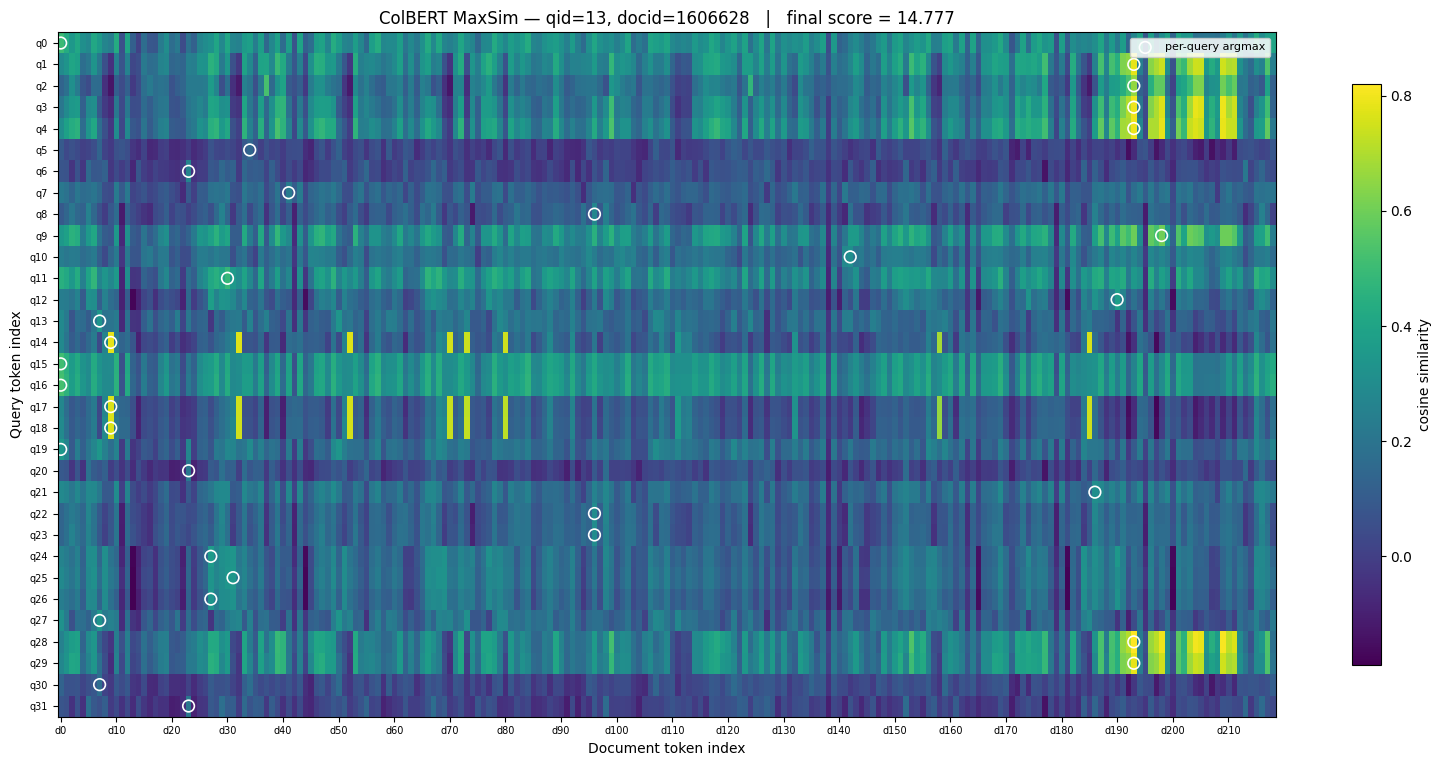

Saved -> /home/kaiyul3/cs410-tech-review/results/figures/colbert_maxsim_q13.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

S_np = S.detach().cpu().numpy()
nq, nd = S_np.shape
argmax_d = S_np.argmax(axis=1)

fig_w = float(np.clip(0.16 * nd + 4, 8, 16))
fig_h = float(np.clip(0.18 * nq + 2, 5, 9))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(S_np, aspect="auto", cmap="viridis")
ax.scatter(argmax_d, np.arange(nq),
           facecolors="none", edgecolors="white", linewidths=1.2, s=70,
           label="per-query argmax")

# Rough labels: indices, not WordPiece strings.
xtick_step = max(1, nd // 20)
xtick_pos  = np.arange(0, nd, xtick_step)
ax.set_xticks(xtick_pos)
ax.set_xticklabels([f"d{i}" for i in xtick_pos], fontsize=7)
ax.set_yticks(np.arange(nq))
ax.set_yticklabels([f"q{i}" for i in range(nq)], fontsize=7)

ax.set_xlabel("Document token index")
ax.set_ylabel("Query token index")
ax.set_title(
    f"ColBERT MaxSim — qid={QID}, docid={DOCID}   |   "
    f"final score = {final_score:.3f}"
)
ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("cosine similarity")

fig.tight_layout()
out_path = FIGURES_DIR / "colbert_maxsim_q13.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_path}")

## What you're seeing

- ColBERT keeps **one 128-dim embedding per token** for both query and doc.
- For each query token (each row), it picks the **single most similar doc
  token** — the white circle.
- The final score is the **sum** of those per-row maxima.
- That's "late interaction": no early fusion, no pooling, no CLS vector —
  token-level alignment computed at retrieval time.

### Sanity check

The score printed above is computed on un-quantized FP32 embeddings. The
score in `results/runs/colbert_smoke50.trec` for this same `(qid=13,
docid=1606628)` pair was computed against `nbits=2`-quantized centroids in
the index, so the two numbers will be in the same ballpark but not equal.
If your printed score is *much* smaller, near zero, or negative, encoding
is broken — investigate before trusting the figure.